<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2015/Assignment15_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 15.1: Gradient Descent and Linear Regression

**Expected Time = 60 minutes**

**Total Points = 50**

In this activity you will use gradient descent to identify the parameter $\theta_0$ that minimizes the Mean Squared Error of predictions using the model $y = \theta_0  x$.  In this example, you will use a dataset containing information from a credit card company on customers.  Your goal will be to build a linear model to predict the balance using the credit rating.

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
credit = pd.read_csv('/content/sample_data/Credit.csv', index_col=0)

In [3]:
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


<Axes: >

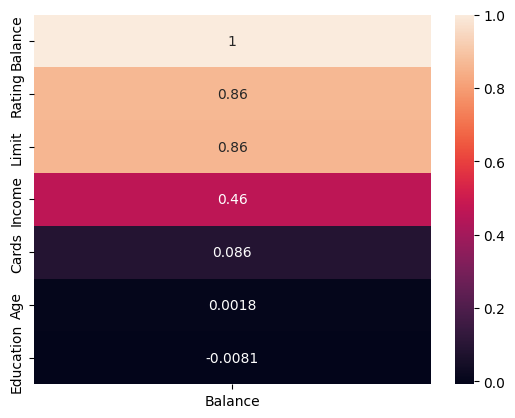

In [4]:
#sns.heatmap(credit.corr()[['Balance']].sort_values(by = 'Balance', ascending = False), annot = True)
corr_matrix = credit.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix[['Balance']].sort_values(by='Balance', ascending=False), annot=True)

In [5]:
X = credit[['Rating']]
y = credit['Balance']

<Axes: xlabel='Rating', ylabel='Balance'>

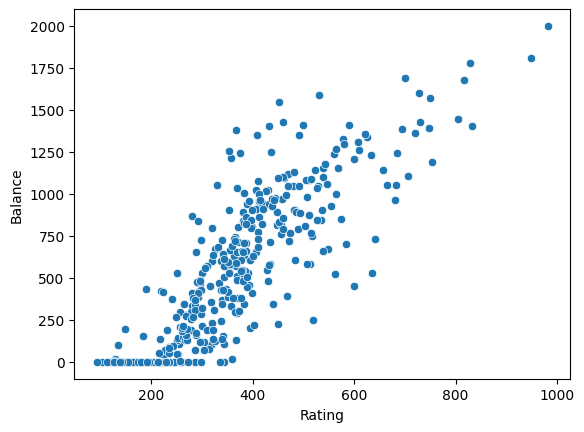

In [6]:
sns.scatterplot(data = credit, x = 'Rating', y = 'Balance', legend=True)

In [7]:
lr = LinearRegression(fit_intercept=False).fit(X,y)

In [8]:
# y_predictions = lr.predict(X)
# y_predictions
lr.intercept_, lr.coef_

(0.0, array([1.64054272]))

In [9]:
pd.DataFrame(y)

,Balance
1,333
2,903
3,580
4,964
5,331
...,...
396,560
397,480
398,138
399,0


[Back to top](#-Index)

### Problem 1

#### A Basic Model

**10 Points**

To begin, complete the function `mse` below that takes in a value for $\theta$ and returns the mean squared error based on the model

$$\text{Balance} = \theta \times \text{Rating}$$

In [10]:
### GRADED
def mse(theta):
    '''
    This function takes in a float for theta and
    returns the mean squared error according to the
    mean of the formula (y - theta*credit['Rating'])**2.

    Arguments
    ---------
    theta: float
          coefficient of linear model

    Returns
    -------
    mse: float
         Mean Squared Error of Linear model against y
    '''
# YOUR CODE HERE
    y_preds = theta*X
    return np.mean((np.array(y)-np.array(y_preds))**2)

### ANSWER CHECK
mse(10)

np.float64(11775994.398)

In [11]:
mse(1.64054272)

np.float64(278997.8702478065)

[Back to top](#-Index)

### Problem 2

#### Considering Many $\theta$'s

**10 Points**

Now, consider the array of thetas given below as `thetas`.  

Use a `for` loop to iterate over the array of thetas and compute the **Mean Squared Error** for the each given $\theta$.  Store these values in the list `mses` below.  

Observe the plot below to view the results.

In [12]:
thetas = np.linspace(-10, 13, 50)

In [13]:
### GRADED
mses = []
for theta in thetas:
    mses.append(mse(theta))

### ANSWER CHECK
mses[-5:]

[np.float64(14914705.921313623),
 np.float64(16339233.287479218),
 np.float64(17829797.354048815),
 np.float64(19386398.12102241),
 np.float64(21009035.5884)]

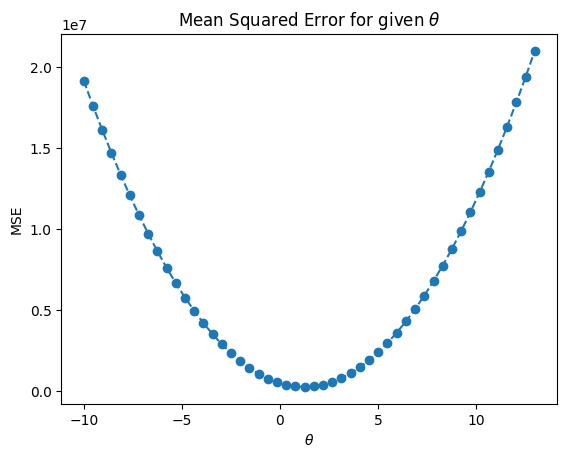

In [16]:
plt.plot(thetas, mses, '--o')
plt.xlabel(r'$\theta$')
plt.ylabel('MSE');
plt.title(r'Mean Squared Error for given $\theta$');

[Back to top](#-Index)

### Problem 3

#### Finding the $\theta$ that minimizes MSE

**10 Points**

Now, you are to use gradient descent with parameters `xs` and `step_size` given below to identify the $\theta$ that minimizes the `mse` function.  


```
- xs = 10
- step_size = 0.1
```

You are given a function `df` to approximate the derivative of the `mse` function.

Use a `for` loop with 200 iterations to calculate the gradient descent of the fucntion `df` given to you below.

Did the algorithm converge to a reasonable value on the last step?  Assign this value to `theta_big_step` as a float below.

In [17]:
def df(x):
    return (mse(x + 0.001) - mse(x))/0.001

In [18]:
## Minimize the loss function - Gradient descent equation is z(t+1)  = z(t) - step_size*df(x)
### GRADED
xs = [10]
xold= xs[0]
step_size = 0.1
for i in range(200):
    xnew = xold - (step_size *df(xold) )
    xs.append(xnew)
    xold=xnew

theta_big_step = xnew
# YOUR CODE HERE

### ANSWER CHECK
print(theta_big_step)
xs[-5:]

-236430072686614.4


[np.float64(-236430072686614.4),
 np.float64(-236430072686614.4),
 np.float64(-236430072686614.4),
 np.float64(-236430072686614.4),
 np.float64(-236430072686614.4)]

[Back to top](#-Index)

### Problem 4

#### A smaller step size

**10 Points**


Repeat the exercise above but now try using 1000 iterations of the gradient descent algorithm with:

```
x0 = 10
step_size = 0.000001
```

Did the algorithm converge to a reasonable value on the last step?  Assign this value to `theta_small_step` as a float below.

In [20]:
### GRADED
xs = [10]
xold=10
step_size=0.000001
for i in range(1000):
    xnew =(xold - (step_size*df(xold)))
    xs.append(xnew)
    xold=xnew

theta_small_step = xnew
# YOUR CODE HERE
### ANSWER CHECK
xs[-5:]

[np.float64(1.2311263126275744),
 np.float64(1.2311263126275744),
 np.float64(1.2311263126275744),
 np.float64(1.2311263126275744),
 np.float64(1.2311263126275744)]

[Back to top](#-Index)

### Problem 5

#### Checking against `sklearn`

**10 Points**

Finally, you are to compare your solution using the small step size to that obtained from scikitlearn's `LinearRegression` estimator.  Be sure to set `fit_intercept = False`.

After fitting the estimator on `X` and `y`, determine the absolute difference between your solution for $\theta$ from [Problem 4](#-Problem-4) and the `.coef_` attribute of the fit sklearn model.  Assign the result as a float to `error`.

In [22]:
### GRADED
lr = LinearRegression(fit_intercept=False).fit(X,y)
error = ''
# YOUR CODE HERE
error = np.abs(theta_small_step- lr.coef_)

### ANSWER CHECK
print(error)

[0.40941641]
